In [1]:
import markdown
from IPython.display import display, HTML, Markdown

# Custom CSS
custom_css = """
<style>

    h1{
        font-family: 'Georgia';
        color: #34495e;
        border-bottom: 5px solid #3498db;
        padding-bottom: 10px;
        
    }

    h2{
        font-family: 'Georgia';
        color: #34495e;
        border-bottom: 3px solid #3498db;
        padding-bottom: 10px;
        
    }
    
    h3{
        font-family: 'Georgia';
        color: #34495e;
        border-bottom: 3px solid #3498db;
        padding-bottom: 10px;
        
    }
        
    p {
        font-family: 'Arial';
        font-size: 16px;
        color: #2c3e50;
        margin-top: 20px;
        
    }
    
    ul{
    
        color: #34495e;
        font-size: 16px;
    
    }
    
    .reveal .slides section {
    overflow-y: auto !important;
    height: 100% !important;
}
    
</style>
"""

display(HTML(custom_css))

Generazione dataset master (500 elementi, range 0-600)...
Inizio test...
Test completato. Generazione grafici...


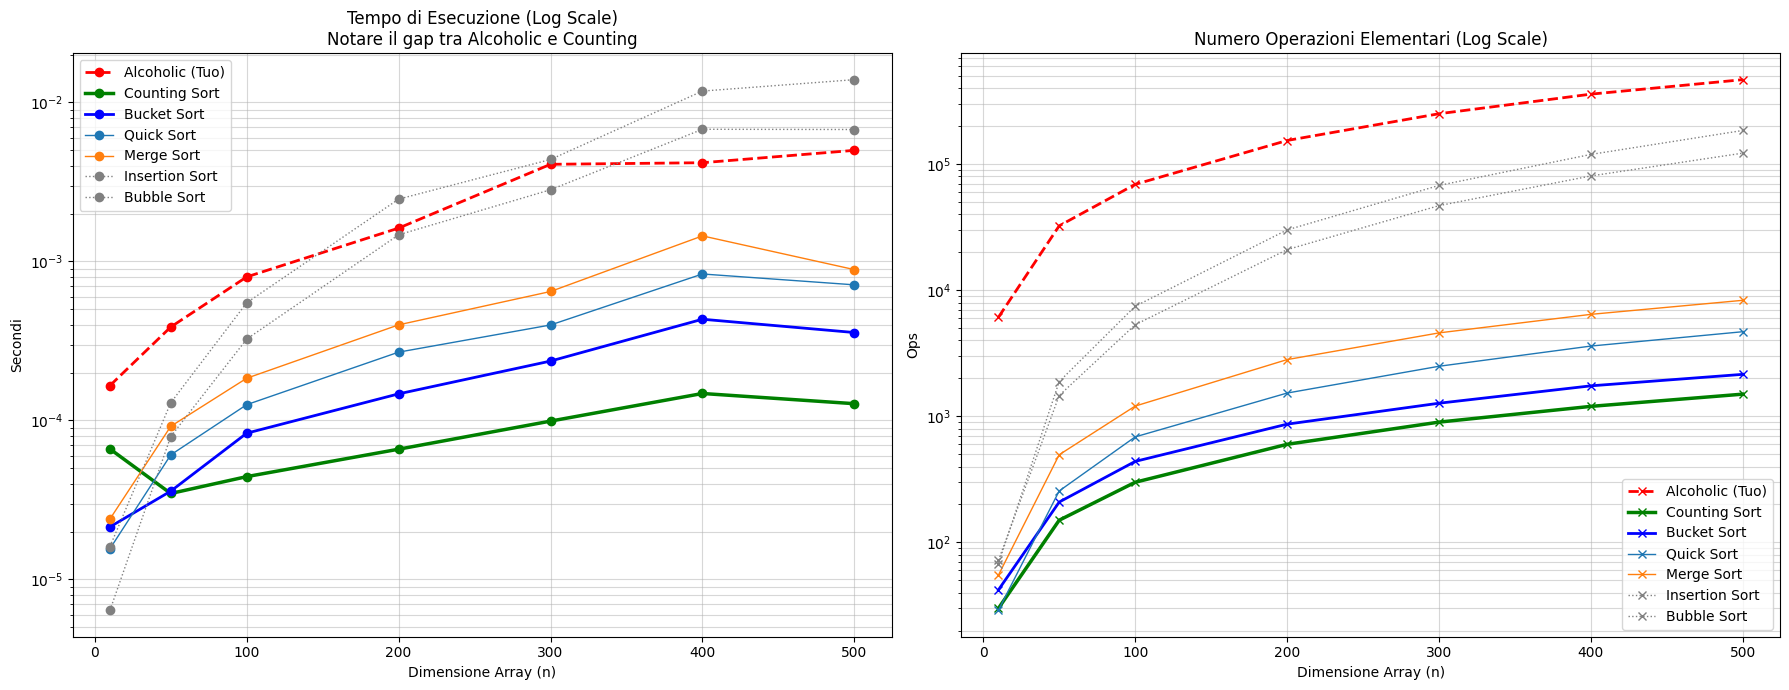

In [30]:
import random
import time
import matplotlib.pyplot as plt
import sys

# Aumentiamo il limite di ricorsione per QuickSort/MergeSort su array grandi
sys.setrecursionlimit(5000)

# ==========================================
# 1. IMPLEMENTAZIONE ALGORITMI
# ==========================================

# --- IL TUO ALGORITMO (Counting Sort "Brute Force") ---
def alcoholic_sort_instrumented(arr):
    arr = list(arr)
    n = len(arr)
    output_list = []
    ops = 0
    
    # Trovare il massimo è necessario per definire il range di ricerca
    if not arr: return [], 0
    max_val = max(arr)
    ops += n # Costo scansione max
    
    current_check = 0
    
    # Ciclo su tutto il range possibile (0 -> Max)
    while len(output_list) < n and current_check <= max_val + 1:
        
        # 1. Scansione "IN": costa O(n)
        ops += len(arr) 
        if current_check in arr:
            
            # 2. Scansione "COUNT": costa O(n)
            ops += len(arr)
            count = arr.count(current_check)
            
            for _ in range(count):
                output_list.append(current_check)
                ops += 1 
        
        current_check += 1
        
    return output_list, ops

# --- COUNTING SORT (La versione ottimizzata del tuo) ---
def counting_sort_instrumented(arr):
    ops = 0
    if not arr: return [], 0
    
    # 1. Troviamo il max per dimensionare l'array di conteggio
    max_val = max(arr)
    ops += len(arr)
    
    # Creiamo le "scatole" (array di frequenza)
    # Spazio: O(M)
    count_array = [0] * (max_val + 1)
    
    # 2. Riempimento delle scatole (Singola passata sull'input)
    # Tempo: O(n)
    for num in arr:
        count_array[num] += 1
        ops += 1 # Accesso diretto (molto veloce!)
        
    output_list = []
    
    # 3. Ricostruzione (Passata sul range dei valori)
    # Tempo: O(M)
    for i in range(max_val + 1):
        while count_array[i] > 0:
            output_list.append(i)
            count_array[i] -= 1
            ops += 1
            
    return output_list, ops

# --- BUCKET SORT ---
def bucket_sort_instrumented(arr):
    n = len(arr)
    if n <= 1: return arr, 0
    ops = 0
    max_val = max(arr)
    ops += n
    
    num_buckets = n
    buckets = [[] for _ in range(num_buckets)]
    
    for num in arr:
        norm_index = int((num * num_buckets) / (max_val + 1))
        buckets[norm_index].append(num)
        ops += 1
        
    sorted_arr = []
    for bucket in buckets:
        # Usa Insertion Sort per i bucket
        sorted_bucket, bucket_ops = insertion_sort_instrumented(bucket)
        ops += bucket_ops
        sorted_arr.extend(sorted_bucket)
        ops += len(sorted_bucket)
        
    return sorted_arr, ops

# --- STANDARD SORTS ---

def insertion_sort_instrumented(arr):
    arr = list(arr)
    ops = 0
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        ops += 1
        while j >= 0:
            ops += 1
            if key < arr[j]:
                arr[j + 1] = arr[j]
                ops += 1
                j -= 1
            else: break
        arr[j + 1] = key
        ops += 1
    return arr, ops

def bubble_sort_instrumented(arr):
    arr = list(arr)
    n = len(arr)
    ops = 0
    for i in range(n):
        for j in range(0, n-i-1):
            ops += 1
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
                ops += 1
    return arr, ops

def merge_sort_instrumented(arr):
    if len(arr) <= 1: return arr, 0
    mid = len(arr) // 2
    left, l_ops = merge_sort_instrumented(arr[:mid])
    right, r_ops = merge_sort_instrumented(arr[mid:])
    merged, m_ops = merge_instrumented(left, right)
    return merged, l_ops + r_ops + m_ops

def merge_instrumented(left, right):
    result = []
    ops = 0
    i = j = 0
    while i < len(left) and j < len(right):
        ops += 1
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
        ops += 1
    result.extend(left[i:])
    result.extend(right[j:])
    ops += len(left[i:]) + len(right[j:])
    return result, ops

def quick_sort_instrumented(arr):
    if len(arr) <= 1: return arr, 0
    pivot = arr[len(arr) // 2]
    ops = len(arr) 
    left = [x for x in arr if x < pivot]
    middle = [x for x in arr if x == pivot]
    right = [x for x in arr if x > pivot]
    s_left, o_left = quick_sort_instrumented(left)
    s_right, o_right = quick_sort_instrumented(right)
    return s_left + middle + s_right, ops + o_left + o_right


# ==========================================
# 2. CONFIGURAZIONE ESPERIMENTO
# ==========================================

# Mappatura funzioni
algorithms = {
    "Alcoholic (Tuo)": alcoholic_sort_instrumented,
    "Counting Sort": counting_sort_instrumented,  # Aggiunto per confronto diretto
    "Bucket Sort": bucket_sort_instrumented,
    "Quick Sort": quick_sort_instrumented,
    "Merge Sort": merge_sort_instrumented,
    "Insertion Sort": insertion_sort_instrumented,
    "Bubble Sort": bubble_sort_instrumented
}

# Dimensioni array da testare
input_sizes = [10, 50, 100, 200, 300, 400, 500]

# Range Valori (Max Valore). 
# IMPORTANTE: Se questo è troppo alto (es. 1.000.000), Alcoholic Sort si blocca.
MAX_VAL = 600 

# Generazione Array Master (Dati Consistenti)
print(f"Generazione dataset master ({max(input_sizes)} elementi, range 0-{MAX_VAL})...")
MASTER_ARRAY = [random.randint(0, MAX_VAL) for _ in range(max(input_sizes))]

results_time = {name: [] for name in algorithms}
results_ops = {name: [] for name in algorithms}

# ==========================================
# 3. ESECUZIONE BENCHMARK
# ==========================================

print("Inizio test...")

for size in input_sizes:
    # Prendiamo una fetta sempre più grande dello stesso array
    current_slice = MASTER_ARRAY[:size]
    
    for name, func in algorithms.items():
        # Copia difensiva (per non ordinare l'array originale in-place)
        test_data = list(current_slice)
        
        start = time.perf_counter()
        _, ops_count = func(test_data)
        end = time.perf_counter()
        
        results_time[name].append(end - start)
        results_ops[name].append(ops_count)

print("Test completato. Generazione grafici...")

# ==========================================
# 4. GRAFICI
# ==========================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Funzione helper per stile
def get_style(algo_name):
    if "Alcoholic" in algo_name: return '--', 2.0, 'red'  # Tuo (Evidenziato in rosso tratteggiato)
    if "Counting" in algo_name: return '-', 2.5, 'green'  # Counting (Evidenziato in verde solido)
    if "Bucket" in algo_name: return '-', 2.0, 'blue'
    if "Quick" in algo_name or "Merge" in algo_name: return '-', 1.0, None
    return ':', 1.0, 'gray' # I lenti (Bubble, Insertion)

# Plot Tempo
for name, times in results_time.items():
    ls, lw, col = get_style(name)
    ax1.plot(input_sizes, times, label=name, linestyle=ls, linewidth=lw, color=col, marker='o')

ax1.set_title(f'Tempo di Esecuzione (Log Scale)\nNotare il gap tra Alcoholic e Counting')
ax1.set_xlabel('Dimensione Array (n)')
ax1.set_ylabel('Secondi')
ax1.set_yscale('log')
ax1.grid(True, which="both", ls="-", alpha=0.5)
ax1.legend()

# Plot Operazioni
for name, ops in results_ops.items():
    ls, lw, col = get_style(name)
    ax2.plot(input_sizes, ops, label=name, linestyle=ls, linewidth=lw, color=col, marker='x')

ax2.set_title('Numero Operazioni Elementari (Log Scale)')
ax2.set_xlabel('Dimensione Array (n)')
ax2.set_ylabel('Ops')
ax2.set_yscale('log')
ax2.grid(True, which="both", ls="-", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

# prima lezione laboratorio

## Es.1
Completare la funzione sum in modo che riceva in input due interi, x e y, e restituisca la loro somma.

Esempio:
sum(5, 7) == 12



In [2]:
def sum(x, y):
    return x + y
sum(5, 7) 

12

## Es.2
Scrivere una funzione suffixes che, ricevuta una stringa in input, restituisca l'array contenente tutti i suoi suffissi, ordinati dal più lungo al più corto.

Nota: la stringa in input può essere vuota o contenere anche un solo carattere.

Esempio:
suffixes("Hello") == ["Hello", "ello", "llo", "lo", "o", ""]

In [3]:
# Esempio:
# suffixes("Hello") == ["Hello", "ello", "llo", "lo", "o", ""]
def suffixes(s):
    result = []
    for i in range(len(s) + 1):
        result.append(s[i:])
    return result

suffixes("Hello")

['Hello', 'ello', 'llo', 'lo', 'o', '']

## Es.3
Scrivere una funzione prefixes che, ricevuta una stringa in input, restituisca l'array contenente tutti i suoi prefissi, ordinati dal più lungo al più corto.

Nota: la stringa in input può essere vuota o contenere anche un solo carattere.

Esempio:
prefixes("Hello") == ["Hello", "Hell", "Hel", "He", "H", ""]

In [4]:
def prefixes(s):
    result = []
    for i in range(len(s) + 1):
        result.append(s[:i])
    
    return result[::-1]

prefixes("Hello")

['Hello', 'Hell', 'Hel', 'He', 'H', '']

## Es.4
Scrivere una funzione reverse che, ricevuto un array di interi in input, restituisca l'array nell'ordine inverso.

Esempio:
reverse([1, 2, 3, 4, 5]) == [5, 4, 3, 2, 1]

In [5]:
def reverse(a):
    return a[::-1]
reverse([1, 2, 3, 4, 5])

[5, 4, 3, 2, 1]

## Es.5
Scrivere una funzione collatz_len che, ricevuto in input un intero positivo n, restituisca la lunghezza della sequenza di Collatz che parte da n.

La sequenza di Collatz che parte da n>0
 è definita tramite il seguente processo ricorsivo:

- se il numero corrente m è pari, lo si sostituisce con la sua metà, ovvero m/2,
- altrimenti, se m è dispari, lo si sostituisce con 3m+1.
Il procedimento prosegue applicando la stessa regola al nuovo valore e si interrompe quando si raggiunge il valore 1. La lunghezza della sequenza è il numero di valori prodotti, includendo il valore iniziale n
 e il valore 1 finale.

Esempio:
collatz_len(3) == 8    // testimoniato dalla sequenza 3 -> 10 -> 5 -> 16 -> 8 -> 4 -> 2 -> 1


Qual'è la complessità della procedura?

In [6]:
def collatz_len(n):
    if n != 1:
        if n % 2 == 0:
            return collatz_len(n/2) + 1
        else:
            return collatz_len(3*n + 1) + 1
    else:
        return 1

collatz_len(3)

8

## Es.6
implementare un algoritmo di ricerca dicotomica su array ordinati di interi.

Nello specifico, scrivere una funzione search che riceva in input un array ordinato di interi e una chiave, e restituisca la posizione della chiave nell'array se questa esiste, altrimenti None. La complessità asintotica della funzione dovrà essere O(logn)
, dove n
 è la lunghezza dell'array.

Esempi: <br>
search([3, 7, 8, 11, 15, 24], 15) == 4 <br>
search([3, 7, 8, 11, 15, 24], 16) == None

In [7]:
def search(a, x):
    left = 0
    right = len(a) - 1

    while left <= right:
        mid = (left + right) // 2
        if a[mid] == x:
            return mid
        elif a[mid] < x:
            left = mid + 1
        else:
            right = mid - 1

    return None

print(search([3, 7, 8, 11, 15, 24], 15),
search([3, 7, 8, 11, 15, 24], 16),
search([1,2,3,4,5,6,7,8,9], 0))

4 None None


## Es.7
Scrivere una funzione count che riceva in input un array ordinato di interi e una chiave, e restituisca il numero di occorrenze di quella chiave nell'array. La complessità asintotica della funzione dovrà essere O(logn), dove n
 è la lunghezza dell'array.

Esempi:
count([3, 7, 8, 11, 15, 24], 15) == 1 <br>
count([3, 7, 7, 7, 15, 15], 7) == 3

In [8]:
"""
def count(a, x):
    if not a:
        return 0
    if a[0]==x:
        return count(a[1:],x) + 1
    else:
        return count(a[1:],x) + 0

print(count([3, 7, 8, 11, 15, 24], 15),
count([3, 7, 7, 7, 15, 15], 7))
"""
def find_first(a, x):
    left, right = 0, len(a) - 1
    result = -1

    while left <= right:
        mid = (left + right) // 2
        if a[mid] == x:
            result = mid
            right = mid - 1    # keep searching left side
        elif a[mid] < x:
            left = mid + 1
        else:
            right = mid - 1

    return result


def find_last(a, x):
    left, right = 0, len(a) - 1
    result = -1

    while left <= right:
        mid = (left + right) // 2
        if a[mid] == x:
            result = mid
            left = mid + 1     # keep searching right side
        elif a[mid] < x:
            left = mid + 1
        else:
            right = mid - 1

    return result


def count(a, x):
    first = find_first(a, x)
    if first == -1:
        return 0
    last = find_last(a, x)
    return last - first + 1


# Test
print(count([3, 7, 8, 11, 15, 24], 15))   # 1
print(count([3, 7, 7, 7, 15, 15], 7))     # 3


1
3


## Es.8
Scrivere una funzione find_pair_with_sum che riceva in input un array a
 ordinato di interi e un intero s
, e restituisca una qualunque coppia (i,j)
 di posizioni nell'array a
 tale che i<j
 e a[i]+a[j]=s
. Se una tale coppia (i,j)
 non dovesse esistere, la funzione dovrà restituire None. 

Esempio:
find_pair_with_sum([3, 7, 8, 11, 15, 20, 24], 23) == (0, 5)    (oppure (2, 4))

Provare a implementare tre versioni dell'algoritmo che abbiano i seguenti tempi asintotici di esecuzione: 
- O(n2)
, 
- O(nlogn)

- O(n)
.

Suggerimento per l'implementazione in tempo lineare: provare a considerare la matrice che riporta la somma a[i]+a[j]
 in corrispondenza di ogni coordinata (i,j)
, con i<j
. Ad esempio, per l'array a
 = [3, 7, 8, 11, 15], la matrice corrispondente sarà

||10|11|14|18|
|--|--|--|--|--|
|||15|18|22|
|||19|23|
|||||26|
||||||

Considerare quindi l'ordinamento dei valori in ciascuna riga e in ciascuna colonna, e immaginare un algoritmo di ricerca di un elemento dato (ad es. 19) che sfrutti tale ordinamento.


**Es.8,1** $(O(n^2))$:

In [9]:
def find_pair_with_sum(a, x):
    n = len(a)
    for i in range(n):
        for j in range(i + 1, n):
            if a[i] + a[j] == x:
                return i, j
    return None



print(find_pair_with_sum([3, 7, 8, 11, 15, 20, 24], 23))
print(find_pair_with_sum([3, 7, 8, 11, 15, 20, 24], 24))

(0, 5)
None


**Es.8,2:**$(O(n\cdot log_n))$

In [10]:
def find_pair_with_sum(a, x):
    n = len(a)
    for i in range(n):
        targhet = x - a[i]
        j = binary_search(a, i + 1, n - 1, targhet)
        if j is not None:
            return i, j
    return None

def binary_search(a, left, right, targhet):
    while left <= right:
        mid = (left + right)//2
        if a[mid] == targhet:
            return mid
        elif a[mid] < targhet:
            left = mid + 1
        else:
            right = mid - 1  
    return None

print(find_pair_with_sum([3, 7, 8, 11, 15, 20, 24], 23))
print(find_pair_with_sum([3, 7, 8, 11, 15, 20, 24], 24))

(0, 5)
None


**Es.8,3**:$O(n)\$ <br>
PER VISUALIZZARE:

In [11]:
def find_pair_with_sum(a, x):
    matrix = []
    while (len(a))>=1:
        matrix.append(crea_matrix(a,x))
        a=a[1:]
    return matrix

def crea_matrix(a,x):
    l=[]
    n = (len(a)-1)
    for i in range(n):
        if (a[0] + a[i+1]) <= x:
            l.append(a[0]+ a[i+1])
    return l

print(find_pair_with_sum([3, 7, 8, 11, 15, 20, 24], 23))
print(find_pair_with_sum([3, 7, 8, 11, 15, 20, 24], 24))

[[10, 11, 14, 18, 23], [15, 18, 22], [19, 23], [], [], [], []]
[[10, 11, 14, 18, 23], [15, 18, 22], [19, 23], [], [], [], []]


In [12]:
def find_pair_with_sum(a, x):
    i = 0
    j = len(a) - 1

    while i < j:
        s = a[i] + a[j]

        if s == x:
            return i, j
        elif s < x:
            i += 1
        else:
            j -= 1
        
    return None

print(find_pair_with_sum([3, 7, 8, 11, 15, 20, 24], 23))
print(find_pair_with_sum([3, 7, 8, 11, 15, 20, 24], 24))

(0, 5)
None


## Es.9
Scrivere una funzione find_interval_with_sum che riceva in input un array a
 di interi non-negativi (ma non necessariamente ordinato) e un intero s
, e restituisca una qualunque coppia (i,j)
 tale che 0≤i<j≤|a|
 e ∑i≤k<ja[k]=a[i]+a[i+1]+⋯+a[j−1]=s
. Se una tale coppia (i,j)
 non dovesse esistere, la funzione dovrà restituire None. 

Esempio:
find_interval_with_sum([5, 0, 3, 1, 13, 7, 5], 17) == (2, 5)    (oppure (1, 5))

Provare a implementare due versioni dell'algoritmo che abbiano i seguenti tempi asintotici di esecuzione: 
- O(n3)
, 
- Θ(n)
.


Suggerimento per l'implementazione in tempo lineare: come per l'esercizio precedente, provare a considerare la matrice che riporta la somma a[i]+a[i+1]+⋯+a[j−1]
 degli elementi dell'array per ogni intervallo [i,j−1]
, con 0≤i<j≤|a|
. Ad esempio, per l'array a
 = [5, 0, 3, 1, 13], la matrice corrispondente sarà

 
 	5	5	8	9	22
 	 	0	3	4	17
 	 	 	3	4	17
 	 	 	 	1	14
 	 	 	 	 	13

Notare che la dimensione della matrice è (n+1)×(n+1)
, dove n
 è la lunghezza dell'array. Notare anche che ogni somma a[i]+a[i+1]+⋯+a[j−1]
 su un intervallo [i,j−1]
 può essere calcolata come la differenza delle somme sui prefissi [0,j−1]
 e [0,i−1]
. Considerare infine l'ordinamento dei valori in ciascuna riga e in ciascuna colonna, e immaginare un algoritmo di ricerca di un elemento dato (ad es. 17) che sfrutti tale ordinamento.

**Es.9,1:**

In [13]:
def find_interval_with_sum(a, x):
    n= len(a)
    for i in range(n):
        for j in range(i+1,n+1):
            tot=0
            for k in range(i,j):
                tot += a[k]
            if tot == x:
                return i,j
    return None
            

print(find_interval_with_sum([5, 0, 3, 1, 13, 7, 5], 17)) # == (2, 5) o (1,5)
print(find_interval_with_sum([5, 0, 3, 1, 13, 7, 5], 0)) # == (1, 2)

(1, 5)
(1, 2)


**Es.9.2**:

In [14]:
def find_interval_with_sum(a, x):
    n = len(a)
    i = 0
    j = 0
    current_sum = 0

    while j < n:
        current_sum += a[j]
        j += 1

        while current_sum > x and i < j:
            current_sum -= a[i]
            i += 1

        if current_sum == x and i < j:
            return i, j

    return None

    
print(find_interval_with_sum([5, 0, 3, 1, 13, 7, 5], 17)) # == (2, 5) o (1,5)
print(find_interval_with_sum([5, 3, 7], 3))
print(find_interval_with_sum([5, 0, 3, 1, 13, 7, 5],18))

(1, 5)
(1, 2)
None


**Versione del prof**:

In [15]:
def find_interval_with_sum(a, s):
	b = [0] * (len(a) + 1)
	for i in range(1, len(a) + 1):
		b[i] = b[i-1] + a[i-1]
		# invariante per il calcolo delle somme dei prefissi di a:
		# b[i] = a[0] + a[1] + ... + a[i-1]
	# ora se voglio calcolare la somma in un intervallo a[i...j-1] (con i<j !!) 
	# uso la proprietà seguente:
	# a[i] + a[i+1] + ... + a[j-1] = b[j] - b[i]
	# notare che: b è ordinato
	i, j = 0, 1
	while 0 <= i < j <= len(a):
		# invariante per la ricerca:
		# se esistesse una soluzione (i',j') con b[j'] - b[i'] = s
		# allora i' >= i e j' >= j
		if b[j] - b[i] < s:		# somma troppo piccola, devo aumentare l'intervallo...
			j = j + 1
		elif b[j] - b[i] > s:	# somma troppo grande, devo diminiire l'intervallo...
			i = i + 1
			# attenzione a non violare il vincolo i < j 
			# per poi uscire erroneamente dal ciclo while!!
			if i == j:
				j = j + 1
		else:
			return (i, j)
	return None

print(find_interval_with_sum([5, 0, 3, 1, 13, 7, 5], 17)) # == (2, 5) o (1,5)
print(find_interval_with_sum([5, 3, 7], 3))
print(find_interval_with_sum([5, 0, 3, 1, 13, 7, 5],18))

(1, 5)
(1, 2)
None


## Es.10
Immaginare che un array a
 di interi rappresenti il prezzo di un'azione che cambia nel tempo e che si voglia massimizzare il profitto di una coppia di operazioni di acquisto e vendita dell'azione stessa. Indichiamo con i
 il momento in cui avviene l'operazione di acquisto, e con j
 il momento in cui avviene l'operazione di vendita: chiaramente avremo che i≤j
 e il profitto sarà determinato dalla differenza a[j]−a[i]
 (il caso i=j
 rappresenta la possibilità di acquistare e vendere nello stesso momento, realizzando un profitto pari a 0). 

Scrivere una funzione find_max_diff che riceva in input l'array a
 di interi (non necessariamente ordinato) e restituisca una coppia (i,j)
 di posizioni nell'array tale che i≤j
 e la differenza a[j]−a[i]
 sia massima.

Esempio:
find_max_diff([14, 16, 1, 5, 13, 0, 3]) == (2, 4)

Provare a implementare due versioni dell'algoritmo che abbiano i seguenti tempi asintotici di esecuzione: 
- O(n2)
, 
- O(n)
.

Suggerimento per la soluzione in tempo lineare:
Provare a risolvere il seguente sottoproblema: immaginando che l'indice j
 sia già noto (ad esempio, che, per qualche motivo, dobbiamo vendere l'azione esattamente nel momento j
), trovare l'indice i
 che massimizza la differenza a[j]−a[i]
 (ovvero, trovare il momento migliore i
 in cui avremmo dovuto comprare l'azione prima di venderla). 

In [16]:
def find_max_diff(a):
    b = [None] * len(a)
    b[0] = 0
    for j in range(1, len(a)):
        if a[j] < a[b[j-1]]:
            b[j] = j
        else:
            b[j] = b[j-1]
    max_diff = float('-inf')
    j_max_diff = None
    for j in range(len(a)):
        diff = a[j] - a[b[j]]
        if diff > max_diff:
            max_diff = diff
            j_max_diff = j

    return (b[j_max_diff], j_max_diff)

print(find_max_diff([14, 16, 1, 5, 13, 0, 3])) 

(2, 4)


## Es.11
Scrivere una funzione majority che riceva in input un array di interi (non necessariamente ordinato) e restituisca l'elemento maggioritario in esso. Un elemento x
 si dice maggioritario in un array a
 se x
 occorre in a
 almeno $⌊\frac{|a|}{2}⌋+1$
 volte. Si noti che l'elemento maggioritario, se esiste, è unico. La funzione majority dovrà restituire precisamente tale elemento, qualora esista, altrimenti il valore None.

**Esempi**:<br>
majority([5, 0, 3, 1, 13, 7, 5]) == None<br>
majority([5, 2, 3, 2, 5, 2, 2], 7) == 3

Provare a implementare alcune versioni della funzione che abbiano i seguenti tempi asintotici di esecuzione:

- $O(n^2)$
- $O(nlog_n)$
- $Θ(n)$

In [17]:
def majority(a):
    candidate = None
    count = 0

    # Phase 1: find candidate
    for x in a:
        if count == 0:
            candidate = x
            count = 1
        elif x == candidate:
            count += 1
        else:
            count -= 1

    # Phase 2: verify
    if candidate is not None and a.count(candidate) > len(a) // 2:
        return candidate
    return None
    
print(majority([5, 0, 3, 1, 13, 7, 5]))
print(majority([5, 2, 3, 2, 5, 2, 2]))

None
2


### Es.11,2

In [18]:
def majority_n2(a):
    n = len(a)
    for i in range(n):
        x = a[i]
        count = 0
        for y in a:
            if y == x:
                count += 1
        if count > n // 2:
            return x
    return None
print(majority_n2([5, 0, 3, 1, 13, 7, 5]))
print(majority_n2([5, 2, 3, 2, 5, 2, 2]))

None
2


### Es.11,3

In [19]:
def majority_nlogn(a):
    if not a:
        return None

    a_sorted = sorted(a)             # O(n log n)
    candidate = a_sorted[len(a)//2]
    count = a_sorted.count(candidate)

    return candidate if count > len(a)//2 else None

print(majority_nlogn([5, 0, 3, 1, 13, 7, 5]))
print(majority_nlogn([5, 2, 3, 2, 5, 2, 2]))

None
2


## Es.12:
Implementare uno o più algoritmi di ordinamento (quick sort, merge sort, heap sort, selection sort, insertion sort, bubble sort, ...) su array di interi. La procedura principale, denominata sort, deve ricevere in input un array di interi e deve restituire l'array ordinato (l'ordinamento può avvenire modificando direttamente l'array fornito in input, a patto che questo venga poi restituito dalla procedura).

Esempio:
sort([7, 3, 11, 5]) == [3, 5, 7, 11]


Variante di quicksort 3way:
Provare ad implementare anche una variante dell'algoritmo quicksort che, nel caso medio, abbia complessità Θ(nlogm)
, dove n
 è la lunghezza dell'array fornito in input e m
 è il numero di valori distinti in esso.

In [58]:
def sort(a):                # wrapper to include possible additional arguments and return sorted array
    quicksort3way(a, 0, len(a)) # change this with any sorting algorithm
    return a


def partition3way(a, i, j):
 pivot = a[j-1]

 h = i
 k = i
 l = i
 while i <= k <= l <= h < j:
  # Invariante:
  #          i     k     l     h           j     
  # a = ... |<|<|>|=|=|=|>|>|>|?|?|?|pivot| ...
  if a[h] < pivot:
   # devo ruotare a[k], a[l], a[h]
   if k < l < h:
    a[k], a[l], a[h] = a[h], a[k], a[l]
   elif k == l < h:
    a[k], a[h] = a[h], a[k]
   elif k < l == h:
    a[k], a[h] = a[h], a[k]
   elif k == l == h:
    pass
   k = k + 1
   l = l + 1
  elif a[h] == pivot:
   # devo scambiare a[l], a[h]
   a[l], a[h] = a[h], a[l]
   l = l + 1
  elif a[h] > pivot:
   pass
  h = h + 1

 return (k, l)



def quicksort3way(a, i, j):
 if j - i <= 1:
  return
 (k, l) = partition3way(a, i, j) # dopo questa chiamata a[k,l] è costante uguale al pivot
 quicksort3way(a, i, k)
 quicksort3way(a, l, j)

print(sort([7, 3, 11, 5]))
print(sort([7,2]))
print(sort([7, 3, 11, 5,9,23,34,57]))

[3, 5, 7, 11]
[2, 7]
[3, 5, 7, 9, 11, 23, 34, 57]


## Es.13
Implementare la struttura dati MinHeap, ovvero un albero binario quasi completo internamente rappresentato come un array, in cui la chiave associata ad ogni nodo è sempre minore o uguale alle chiavi dei suoi figli (se ve ne sono). Tale struttura dovrà supportare le seguenti operazioni:

- build(a): inizializzazione della heap tramite un array a di interi (non necessariamente ordinato); tale procedura dovrà prendere tempo Θ(n), dove n è la dimensione della heap

- insert(key): inserimento di una nuova chiave key.

- get_min(): restituzione della chiave più piccola nella heap,

- extract(): rimozione della chiave più piccola dalla heap,

- change(i, key): assegnazione di una nuova chiave key al nodo in posizione i (secondo la codifica in array dell'albero binario semi-completo); ad esempio, change(0, 10) modifica la chiave minima della heap in 10.

La struttura dati MinHeap dovrà essere implementata come una classe, completando le definizioni dei metodi predisposti qui sotto. Altri metodi privati potranno eventualmente essere aggiunti se ritenuti utili. La verifica avverrà iterando alcune chiamate a questi metodi e verificandone il comportamento atteso.

In [20]:
class MinHeap:
    def __init__(self):
        self.heap = []

    def __len__(self):
        return len(self.heap)

    def __str__(self):
        return str(self.heap)


    def _parent(self, i):
        return (i - 1) // 2 if i > 0 else None

    def _left(self, i):
        return 2 * i + 1 if 2 * i + 1 < len(self) else None

    def _right(self, i):
        return 2 * i + 2 if 2 * i + 2 < len(self) else None


    def build(self, a):
        self.heap = list(a)
        for i in range(len(self.heap) - 1, -1, -1):
            self._heapify_down(i)

    def insert(self, key):
        self.heap.append(key)
        self._heapify_up(len(self.heap) - 1)

    def get_min(self):
        return self.heap[0]

    def extract(self):
        key = self.heap[0]
        self.heap[0] = self.heap[len(self.heap) - 1]
        self.heap.pop()
        self._heapify_down(0)
        return key

    def change(self, i, key):
        old = self.heap[i]
        self.heap[i] = key
        if key < old:
            self._heapify_up(i)
        elif key > old:
            self._heapify_down(i)


    def _heapify_up(self, i):
        # idea: 
        # 1) guardo al genitore (se esiste!)
        # 2) se il genitore è più grande di self.heap[i], allora lo scambio con self.heap[i]
        #    e ricorsivamente correggo verso l'alto....
        p = self._parent(i)
        if p is not None and self.heap[p] > self.heap[i]:
            self.heap[i], self.heap[p] = self.heap[p], self.heap[i]
            self._heapify_up(p)

    def _heapify_down(self, i):
        # idea: 
        # 1) guardo al nodo corrente e ai figli sx e dx (se esistono!), 
        # 2) scelgo il più piccolo fra questi nodi, e se diverso self.heap[i] lo scambio con self.heap[i]
        #    e ricorsivamente correggo verso il basso....
        l = self._left(i)
        r = self._right(i)
        j = i # j sarà la posizione della chiave più piccola tra heap[i] e i suoi figli
        if l is not None and self.heap[l] < self.heap[j]:
            j = l
        if r is not None and self.heap[r] < self.heap[j]:
            j = r
        if j != i:
            self.heap[i], self.heap[j] = self.heap[j], self.heap[i]
            self._heapify_down(j)

## Es.14
implementare una funzione select che risolva il problema della selezione in un array dato. Precisamente, la funzione dovrà ricevere in input un array a
 di interi (non necessariamente ordinato) e un intero k
, con 0≤k<|a|
, e dovrà restituire il k+1
-esimo elemento più piccolo dell'array, ovvero l'elemento che apparirebbe in posizione k
 una volta che l'array fosse ordinato. 

Esempio:
select([7, 3, 11, 5], 1) == 5

La funzione dovrà implementare uno dei seguenti algoritmi:

1) Variante dell'algoritmo di ordinamento "quick sort", in cui ad ogni passo induttivo si effettua una sola chiamata ricorsiva, precisamente su un'intervallo [i,j]
 dell'array che contiene k
.

2) Variante basata sull'utilizzo di una heap ausiliaria, ovvero:
- costruzione di una heap principale statica, denominata H1
, a partire dall'array fornito in input
- costruzione di una heap ausiliaria, denominata H2
, inizialmente contenente un solo nodo con la posizione dell'elemento minimo nella heap H1
 (i nodi nella heap H2
 contengono posizioni, ma vengono confrontati attraverso i valori degli elementi corrispondenti in H1
)
- esecuzione per k
 volte delle seguenti operazioni: estrazione del nodo di peso minimo da H2
, corrispondente a un nodo x
 nella heap H1
, seguito da inserimento in H2
 dei nodi corrispondenti ai figli sinistro e destro di x
 in H1
. 

3) Variante basata sul calcolo della mediana delle mediane, ovvero:
- divisione dell'array in blocchi di 5 elementi, escluso eventualmente l'ultimo blocco che potrà contenere meno di 5 elementi,
- ordinamento e calcolo della mediana di ciascun blocco,
- calcolo della mediana M
 delle mediane dei blocchi, attraverso chiamata ricorsiva allo stesso algoritmo
- partizionamento dell'intero array attorno alla mediana M
, attraverso una variante della procedura "partition" dell'algoritmo "quick sort"
- chiamata ricorsiva nella parte di array che sta a sinistra o a destra della mediana M
, in funzione del valore k
 fornito in input.
(nota: il modo più semplice per implementare quest'ultimo algoritmo consiste nel creare, ad ogni chiamata ricorsiva, un nuovo array, per memorizzare, ad esempio, le mediane dei blocchi - esiste tuttavia un approccio più efficiente e "in place" che riutilizza lo spazio allocato per l'array fornito in input).

*** Analizzare la complessità asintotica dei suddetti algoritmi nel caso pessimo e nel caso medio e dimostrare che:
- l'algoritmo 1) ha complessità O(n2)
 nel caso pessimo e Θ(n)
 nel caso medio,
- l'algoritmo 2) ha complessità O(n+klog(k+1))
 sia nel caso pessimo che nel caso medio,
- l'algoritmo 3) ha complessità Θ(n)
 sia nel caso pessimo che nel caso medio.

In [21]:
# selezione basata su due min heap, una statica e una dinamica (da completare)

def select(a, k):
    # return quickselect(a, k, 0, len(a))
    return heapselect(a, k)
    # return momselect(a, k, ...)


class MinHeap:
    def __init__(self):
        self.heap = []

    def __len__(self):
        return len(self.heap)

    def __str__(self):
        return str(self.heap)


    def _parent(self, i):
        return (i - 1) // 2 if i > 0 else None

    def _left(self, i):
        return 2 * i + 1 if 2 * i + 1 < len(self) else None

    def _right(self, i):
        return 2 * i + 2 if 2 * i + 2 < len(self) else None


    def build(self, a):
        self.heap = list(a)
        for i in range(len(self.heap) - 1, -1, -1):
            self._heapify_down(i)

    def insert(self, key):
        self.heap.append(key)
        self._heapify_up(len(self.heap) - 1)

    def get_min(self):
        return self.heap[0]

    def extract(self):
        key = self.heap[0]
        self.heap[0] = self.heap[len(self.heap) - 1]
        self.heap.pop()
        self._heapify_down(0)
        return key

    def change(self, i, key):
        old = self.heap[i]
        self.heap[i] = key
        if key < old:
            self._heapify_up(i)
        elif key > old:
            self._heapify_down(i)


    def _heapify_up(self, i):
        # idea: 
        # 1) guardo al genitore (se esiste!)
        # 2) se il genitore è più grande di self.heap[i], allora lo scambio con self.heap[i]
        #    e ricorsivamente correggo verso l'alto....
        p = self._parent(i)
        if p is not None and self.heap[p] > self.heap[i]:
            self.heap[i], self.heap[p] = self.heap[p], self.heap[i]
            self._heapify_up(p)

    def _heapify_down(self, i):
        # idea: 
        # 1) guardo al nodo corrente e ai figli sx e dx (se esistono!), 
        # 2) scelgo il più piccolo fra questi nodi, e se diverso self.heap[i] lo scambio con self.heap[i]
        #    e ricorsivamente correggo verso il basso....
        l = self._left(i)
        r = self._right(i)
        j = i # j sarà la posizione della chiave più piccola tra heap[i] e i suoi figli
        if l is not None and self.heap[l] < self.heap[j]:
            j = l
        if r is not None and self.heap[r] < self.heap[j]:
            j = r
        if j != i:
            self.heap[i], self.heap[j] = self.heap[j], self.heap[i]
            self._heapify_down(j)


class AuxMinHeap:
  # implementare la min heap ausiliaria
  # i cui elementi sono coppie (valore, posizione)
  # (le posizioni saranno riferite ad una heap statica)


    def heapselect(a, k):
        H1 = MinHeap()
        H1.build(a)  # tempo lineare in a: O(n)

        H2 = AuxMinHeap()
        H2.build( [ (H1.get_min(), 0) ] )

        for i in range(k+1):   # k + 1 volte
            (value, pos) = H2.extract()   # O(log (k+1))
            pos_sx = H1._left(pos)    
            pos_dx = H1._right(pos)    
            if pos_sx is not None:
                H2.insert( (H1.heap[pos_sx], pos_sx) ) # O(log (k+1))
            if pos_dx is not None:
                H2.insert( (H1.heap[pos_dx], pos_dx) ) # O(log (k+1))
        return value

## Es.15
Scrivere una funzione inorder_visit che, dato un albero binario, restituisca l'array risultante dalla sua visita in-order. Precisamente, l'albero viene fornito in input tramite un puntatore alla sua radice; la radice, così come qualunque altro nodo dell'albero, sarà un oggetto (istanza della classe TreeNode) contenente una chiave key di tipo numerico (intero) e due puntatori, left e right, rispettivamente ai figli sinistro e destro (questi puntatori potrebbero essere None qualora i sottoalberi radicati in essi fossero vuoti). 

Esempio:

inorder_visit(TreeNode(2, TreeNode(1), TreeNode(3))) == [1, 2, 3]

Nota 1: fare attenzione alla complessità della funzione implementata, che dovrà essere lineare. In particolare, evitare le operazioni di concatenazione sulle liste/array; l'utilizzo della funzione append è ammesso, ricordando però che la sua complessità ammortizzata è costante, mentre nel caso pessimo l'esecuzione di una singola istruzione append può prendere anche tempo lineare rispetto alla dimensione degli array coinvolti.

Nota 2: in caso di errore durante la fase di verifica, l'albero fornito in input sarà presentato tramite un array di chiavi o di valori None, secondo la rappresentazione degli alberi in forma polacca, simile ad una visita in pre-order. Precisamente, la rappresentazione in forma polacca di un albero binario non vuoto è l'array che comincia con la chiave associata al nodo radice e continua con la rappresentazione del sotto-albero sinistro, seguita da quella del sotto-albero destro. Qualora l'albero fosse vuoto, la sua rappresentazione in forma polacca consisterebbe nell'array singoletto [None]. Ad esempio, l'albero TreeNode(2, TreeNode(1), TreeNode(3)) dell'esempio qui sopra, verrebbe rappresentato dall'array [2, 1, None, None, 3, None, None]. 

In [22]:
class TreeNode:
    def __init__(self, key, left = None, right = None):
        self.key = key
        self.left = left
        self.right = right
        
#---------------------------------------
#   Soluzione semplice ma INEFFICENTE:
#--------------------------------------

# complessità quadratica a causa della concatenzione di array

'''
def inorder_visit(root):
    if root is None:
        return []
    return inorder_visit(root.left)+[root.key] + inorder_visit(root.right)
    inorder_visit(root.left)
    inorder_visit(root.right)
'''

#---------------------------------------
#   Soluzione EFFICENTE:
#--------------------------------------


def inorder_visit(root):
    a=[]
    append_inorder(root, a)
    return a

def append_inorder(root, a):
    if root is None:
        return
    append_inorder(root.left ,a)
    a.append(root.key)
    append_inorder(root.right, a)


print(inorder_visit(TreeNode(2, TreeNode(1), TreeNode(3)))) # == [1, 2, 3]
print(inorder_visit(TreeNode(10, TreeNode(5, TreeNode(2), TreeNode(7)),TreeNode(20)))) # == [2, 5, 7, 10, 20]

[1, 2, 3]
[2, 5, 7, 10, 20]


## **Es.16**
Scrivere una funzione verify_BST che riceva in input un albero binario in cui ogni nodo contiene una chiave numerica key e decida se questo sia o meno un albero binario di ricerca, vale a dire, se l'albero soddisfi o meno la seguente proprietà: per ogni nodo x
 dell'albero e per ogni suo discendente y
 nel sotto-albero di sinistra (rispettivamente, di destra), la chiave di x
 deve essere strettamente maggiore (rispettivamente, minore) di quella di y
. In particolare, in un albero binario di ricerca i nodi hanno sempre chiavi distinte e la loro visita in-order produce un array ordinato. 

Esempi: <br>
verify_BST(TreeNode(1, None, TreeNode(2, None, TreeNode(3, None, None)))) == True <br>
verify_BST(TreeNode(1, TreeNode(2, None, TreeNode(3, None, None))), None) == False

In [23]:
class TreeNode:
    def __init__(self, key, left = None, right = None):
        self.key = key
        self.left = left
        self.right = right
        self.parent = None
        if left is not None:
            left.parent = self
        if right is not None:
            right.parent = self


class BST:
    def __init__(self, root = None):
        self.root = root
    
    def find(self, key):
        pass

    def nxt(self, node):
        pass

    def prv(self, node):
        pass

    def insert(self, node):
        pass

    def remove(self, node):
        pass

    def rotate_right(self, node):
        pass

    def rotate_left(self, node):
        pass

#--------------------------------------
# Soluzione corretta ma NON EFFICENTE
#--------------------------------------

'''
def verify_BST:
    a = inorder_visit(root)
    for i in range(len(a)-1):
        if a[i]>=a[i+2]
            return False
    return True
'''



#------------------------
#   Soluzione EFFICENTE
#------------------------

def verify_BST(root, low = None, high = None):
    if root is None:
        return True
    if low is not None and root.key <= low:
        return False
    if high is not None and root.key >= high:
        return False
    (...)

print( verify_BST(TreeNode(1, None, TreeNode(2, None, TreeNode(3, None, None)))), # == True
verify_BST(TreeNode(1, TreeNode(2, None, TreeNode(3, None, None))), None) # == False
     )


None None


## Es.17
Scrivere una funzione decode_BST che riceva in input un array non vuoto di numeri interi e restituisca l'albero binario di ricerca la cui visita pre-order coincida con l'array stesso. Precisamente, ciascun nodo dell'albero dovrà essere un oggetto (istanza della classe TreeNode) contenente una chiave numerica key e due puntatori, left e right, alle radici dei sottoalberi sinistro e destro del nodo stesso. L'albero dovrà essere restituito tramite un puntatore alla sua radice (eventualmente None, se l'albero fosse vuoto). 

Esempio:
decode_BST([2, 1, 3]) == TreeNode(2, TreeNode(1), TreeNode(3)) 

Nota: la visita pre-order di un albero vuoto restituisce l'array vuoto [].

|<|<|<|X|>|>|>|>|<|<|
|-|-|-|-|-|-|-|-|-|-|

In [21]:
class TreeNode:
    def __init__(self, key, left = None, right = None):
        self.key = key
        self.left = left
        self.right = right

    def __str__(self):
        s = f"{self.key} "
        if self.left != None:
            s = s + self.left.__str__()
        else:
            s = s + "NULL "
        if self.right != None:
            s = s + self.right.__str__()
        else:
            s = s + "NULL "
        return s


def decode_BST(a):
    (tree, new_offstet) = decode_BST_aux(a,0, float('+inf'))
    return tree

def decode_BST_aux(a, offset, limite):
    if offset >= len(a) or a[offset] > limite:
        return (None, offset)
    
    key = a[offset]
    (left,new_offset) = decode_BST_aux(a,offset +1, key)
    (right, new_offset2) = decode_BST_aux(a, new_offset, limite)
    return (TreeNode(key,left, right),new_offset2)
    


tree = decode_BST([20,5,10,30])

print(tree)

20 5 NULL 10 NULL NULL 30 NULL NULL 


## Es.18
Implementare un albero binario di ricerca che supporti le seguenti operazioni:
- find(key), ricerca di una chiave e restituzione del nodo che la contiene, oppure None se la chiave non esiste,
- nxt(node), restituzione del nodo successore nella visita in-order (None se il successore non esiste),
- prv(node), restituzione del nodo predecessore nella visita in-order (None se il predecessore non esiste),
- insert(node), inserimento di un nodo con una nuova chiave,
- remove(node), rimozione di un nodo esistente dall'albero,
- rotate_left(node), rotazione a sinistra sul nodo che funge da perno (esso dovrà avere necessariamente il figlio destro),
- rotate_right(node), rotazione a destra sul nodo che funge da perno (esso dovrà avere necessariamente il figlio sinistro).

La struttura dati dovrà essere implementata tramite una classe denominata BST, che contiene un attributo root per memorizzare la radice dell'albero. Ogni nodo, istanza della classe TreeNode, dovrà avere un attributo key contente la chiave e tre puntatori, left, right e parent, rispettivamente al figlio sinistro, al figlio destro e al genitore.

Nota: è possibile implementare un'operazione alla volta, nell'ordine indicato sopra, e superare parzialmente i test predisposti.

In [6]:
class TreeNode:
    def __init__(self, key, left = None, right = None):
        self.key = key
        self.left = left
        self.right = right
        self.parent = None
        if left is not None:
            left.parent = self
        if right is not None:
            right.parent = self


class BST:
    def __init__(self, root = None):
        self.root = root
    
    def __str__(self):
        if self.root == None:
            return "NULL "
        else:
            return f"{self.root.key} " + BST(self.root.left).__str__() + BST(self.root.right).__str__()

    def find(self,key):
        curr = self.root
        while curr != None:
            if key == curr.key:
                return curr
            elif key < curr.key:
                curr = curr.left
            else: 
                curr = curr.right
        return None
            
            

    def nxt(self, node):
        #assert node != None
        print(node)
        if node.right != None:
            # scendo lungo la spina sinistra
            curr = node.right
            while curr.left != None:
                curr = curr.left
            return curr
        else:
            # prima salgo sulla spina sinistra
            curr = node
            while curr.parent != None and curr.parent.right == curr:
                curr = curr.parent
            curr = curr.parent
            return curr



        

    def prv(self, node):
        pass

    def insert(self, node):
        pass

    def remove(self, node):
        pass

    def rotate_right(self, node):
        pass

    def rotate_left(self, node):
        pass



t = BST(TreeNode(20, TreeNode(10), TreeNode(30)))
print(t.nxt(t.find(10).key))

10


AttributeError: 'int' object has no attribute 'right'

In [ ]:
find(self,key)